In [1]:
import numpy as np
from scipy.signal import sosfilt

Fs = 48000


def low_shelf(fc, gain_db, fs=Fs, S=1):
    A = 10 ** (gain_db / 40)
    w0 = 2 * np.pi * fc / fs
    alpha = np.sin(w0) / 2 * np.sqrt(
        (A + 1 / A) * (1 / S - 1) + 2
    )

    b0 = A * ((A + 1) - (A - 1) * np.cos(w0) + 2 * np.sqrt(A) * alpha)
    b1 = 2 * A * ((A - 1) - (A + 1) * np.cos(w0))
    b2 = A * ((A + 1) - (A - 1) * np.cos(w0) - 2 * np.sqrt(A) * alpha)

    a0 = (A + 1) + (A - 1) * np.cos(w0) + 2 * np.sqrt(A) * alpha
    a1 = -2 * ((A - 1) + (A + 1) * np.cos(w0))
    a2 = (A + 1) + (A - 1) * np.cos(w0) - 2 * np.sqrt(A) * alpha

    return np.array([
        [b0 / a0, b1 / a0, b2 / a0,
         1, a1 / a0, a2 / a0]
    ])


def high_shelf(fc, gain_db, fs=Fs, S=1):
    A = 10 ** (gain_db / 40)
    w0 = 2 * np.pi * fc / fs
    alpha = np.sin(w0) / 2 * np.sqrt(
        (A + 1 / A) * (1 / S - 1) + 2
    )

    b0 = A * ((A + 1) + (A - 1) * np.cos(w0) + 2 * np.sqrt(A) * alpha)
    b1 = -2 * A * ((A - 1) + (A + 1) * np.cos(w0))
    b2 = A * ((A + 1) + (A - 1) * np.cos(w0) - 2 * np.sqrt(A) * alpha)

    a0 = (A + 1) - (A - 1) * np.cos(w0) + 2 * np.sqrt(A) * alpha
    a1 = 2 * ((A - 1) - (A + 1) * np.cos(w0))
    a2 = (A + 1) - (A - 1) * np.cos(w0) - 2 * np.sqrt(A) * alpha

    return np.array([
        [b0 / a0, b1 / a0, b2 / a0,
         1, a1 / a0, a2 / a0]
    ])


def peaking(fc, gain_db, Q=1.414, fs=Fs):
    A = 10 ** (gain_db / 40)
    w0 = 2 * np.pi * fc / fs
    alpha = np.sin(w0) / (2 * Q)

    b0 = 1 + alpha * A
    b1 = -2 * np.cos(w0)
    b2 = 1 - alpha * A

    a0 = 1 + alpha / A
    a1 = -2 * np.cos(w0)
    a2 = 1 - alpha / A

    return np.array([
        [b0 / a0, b1 / a0, b2 / a0,
         1, a1 / a0, a2 / a0]
    ])


def process_eq(x, fs=Fs):
    low = low_shelf(200, 6, fs)
    mid1 = peaking(500, -4, 1.414, fs)
    mid2 = peaking(1000, 5, 1.414, fs)
    mid3 = peaking(3000, 4, 1.414, fs)
    high = high_shelf(8000, -5, fs)

    y = sosfilt(low, x)
    y = sosfilt(mid1, y)
    y = sosfilt(mid2, y)
    y = sosfilt(mid3, y)
    y = sosfilt(high, y)

    return y

In [2]:

import numpy as np
from scipy.io.wavfile import read
from IPython.display import Audio, display

Fs_audio, x = read("nhac_trung_thu_harmonics_adsr.wav")

x = x.astype(float)

if x.ndim == 2:
    x = np.mean(x, axis=1)

x = x / np.max(np.abs(x))

y = process_eq(x, Fs_audio)

y = y / np.max(np.abs(y))

display(Audio(x, rate=Fs_audio))
display(Audio(y, rate=Fs_audio))

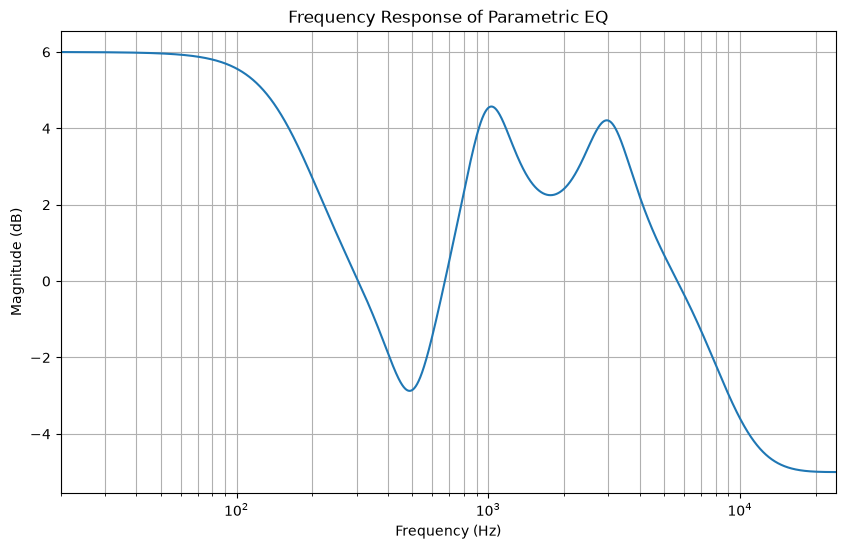

In [3]:
#bt3
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import sosfreqz

filters = [
    low_shelf(200, 6),
    peaking(500, -4, 1.414),
    peaking(1000, 5, 1.414),
    peaking(3000, 4, 1.414),
    high_shelf(8000, -5)
]

f = np.logspace(np.log10(20), np.log10(24000), 8192)

H = np.ones(len(f), dtype=complex)

for sos in filters:
    _, h = sosfreqz(sos, worN=f, fs=Fs)
    H *= h

H_db = 20 * np.log10(np.maximum(np.abs(H), 1e-10))

plt.figure(figsize=(10, 6))
plt.semilogx(f, H_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Frequency Response of Parametric EQ")
plt.xlim(20, 24000)
plt.grid(True, which="both")
plt.show()


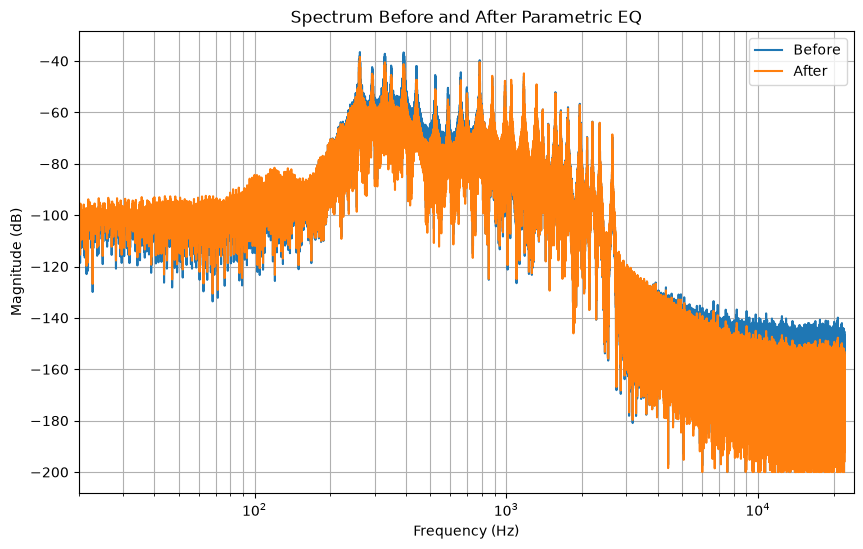

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import read, write
from IPython.display import Audio, display
from scipy.io.wavfile import write

Fs_audio, x = read("nhac_trung_thu_harmonics_adsr.wav")

x = x.astype(float)

if x.ndim == 2:
    x = np.mean(x, axis=1)

x = x / np.max(np.abs(x))

y = process_eq(x, Fs_audio)

y = y / np.max(np.abs(y))

display(Audio(x, rate=Fs_audio))
display(Audio(y, rate=Fs_audio))



write(
    "parametric_eq_output.wav",
    Fs_audio,
    (y / np.max(np.abs(y))).astype(np.float32)
)

N = len(x)

X = np.fft.rfft(x)
Y = np.fft.rfft(y)

f = np.fft.rfftfreq(N, 1 / Fs_audio)

X_db = 20 * np.log10(np.maximum(np.abs(X) / N, 1e-10))
Y_db = 20 * np.log10(np.maximum(np.abs(Y) / N, 1e-10))

plt.figure(figsize=(10, 6))

plt.semilogx(f, X_db, label="Before")
plt.semilogx(f, Y_db, label="After")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Spectrum Before and After Parametric EQ")

plt.xlim(20, 24000)
plt.grid(True, which="both")
plt.legend()

plt.show()